Parcial 1.
nombre: valeria piedrahita osorio.

A. Cargue los datos e identifique cuantas variables categóricas (tipo object) y cuantas variables numéricas tiene.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(r'C:\Users\Valeria\Desktop\curso\class3\spotify-2023.csv', encoding='latin-1')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

Hay 7 categóricas y 17 numéricas. 

B. Desarrolle un algoritmo que nos diga cuantas canciones de Taylor Swift hay en la base de datos.

In [8]:
def taylor_swift():
    i = 0
    for j in df['artist(s)_name']:
        if j == 'Taylor Swift':
            i = i+ 1
    return i

print('La cantidad de registros de Taylor Swift en la base de datos son:', taylor_swift())

La cantidad de registros de Taylor Swift en la base de datos son: 34


C. Encuentre la media de cada columna numérica en la base de datos. (Reporte solo la media de cada variable)

In [31]:
df. describe()
print(df.mean(numeric_only=True))# Media de cada columna numérica

artist_count            1.556139e+00
released_year           2.018238e+03
released_month          6.033578e+00
released_day            1.393075e+01
in_spotify_playlists    5.200125e+03
in_spotify_charts       1.200944e+01
streams                 5.141374e+08
in_apple_playlists      6.781217e+01
in_apple_charts         5.190871e+01
in_deezer_playlists     1.097403e+02
in_deezer_charts        2.666317e+00
in_shazam_charts        5.117634e+01
bpm                     1.225404e+02
danceability_%          6.696957e+01
valence_%               5.143127e+01
energy_%                6.427912e+01
acousticness_%          2.705771e+01
instrumentalness_%      1.581322e+00
liveness_%              1.821301e+01
speechiness_%           1.013116e+01
dtype: float64


D. Desarrolle una función que reciba como parámetro su base de datos y un año de lanzamiento y le devuelva la lista de todas las canciones lanzadas antes año

In [33]:
def canciones_lanzadas(df, year):

	col_name = 'released_year'
	canciones = df[df[col_name] < year]['track_name'].tolist()
	return canciones

year = int(input('Ingrese un año de lanzamiento: '))
print(canciones_lanzadas(df, year))


['Cruel Summer', 'I Wanna Be Yours', 'Blank Space', 'Style', 'Sunflower - Spider-Man: Into the Spider-Verse', 'See You Again', 'Angels Like You', 'Die For You', 'Starboy', 'Another Love', 'Blinding Lights', 'cardigan', 'Yellow', 'Heat Waves', 'Sweater Weather', 'Viva La Vida', 'Riptide', 'STAY (with Justin Bieber)', 'Someone You Loved', 'Makeba', 'MONTAGEM - FR PUNK', 'Donï¿½ï¿½ï¿½t Bl', 'Still With You', 'Summertime Sadness', 'Lover', 'Mockingbird', 'Cold Heart - PNAU Remix', 'Dandelions', 'Bones', 'Set Fire to the Rain', 'Money Trees', 'Everybody Wants To Rule The World', 'No Role Modelz', 'august', 'Por las Noches', "Can't Hold Us (feat. Ray Dalton)", 'Watermelon Sugar', 'lovely - Bonus Track', 'Radio', '505', 'Perfect', 'Believer', 'Without Me', 'Stargirl Interlude', 'Somewhere Only We Know', 'Those Eyes', 'Danza Kuduro', 'Locked Out Of Heaven', 'Counting Stars', 'Ghost', 'Under The Influence', 'Gasolina', 'One Dance', 'Enchanted', 'Save Your Tears', 'Sure Thing', 'Every Breath You

E. Cree una tabla con una función de agregación, que cuente cuantas canciones hay de Taylor Swift y cuantas hay de Adele en la base de datos.

In [49]:
df['artist(s)_name'].unique()
counts = df['artist(s)_name'].value_counts()
table = counts.loc[['Taylor Swift', 'Adele']]
print("Cantidad de canciones por artista:")
print(table)

mean_streams = df[df['artist(s)_name'].isin(['Taylor Swift', 'Adele'])].groupby('artist(s)_name')['streams'].mean()
print("\nPromedio de streams por artista:")
print(mean_streams)

Cantidad de canciones por artista:
artist(s)_name
Taylor Swift    34
Adele            4
Name: count, dtype: int64

Promedio de streams por artista:
artist(s)_name
Adele           1.127187e+09
Taylor Swift    4.133429e+08
Name: streams, dtype: float64


F. Desarrolle un subplot con dos gráficos, el primero es un boxplot relacione artist_count (eje x) con streams, y el segundo un histograma de los años de lanzamiento.

C:\Users\Valeria\AppData\Local\Temp\ipykernel_10056\2502196393.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot([df.loc[0:20000]['streams'], df.loc[0:20000]['artist_count']], labels=['streams', 'artistas'])


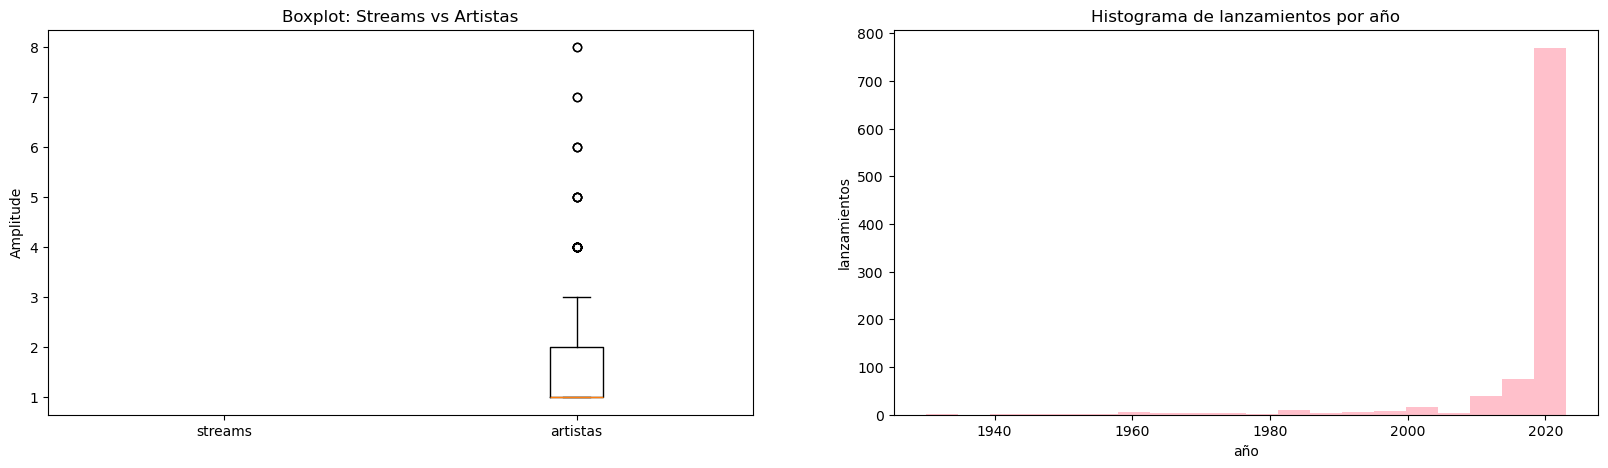

In [63]:
fig, axs=plt.subplots(nrows=1, ncols=2, figsize=(20,5)) 
axs[0].boxplot([df.loc[0:20000]['streams'], df.loc[0:20000]['artist_count']], labels=['streams', 'artistas'])
axs[0].set_ylabel('Amplitude')
axs[0].set_title('Boxplot: Streams vs Artistas')

axs[1].hist(df.loc[0:20000]['released_year'], bins=20, color='pink') 
axs[1].set_xlabel('año')
axs[1].set_ylabel('lanzamientos')
axs[1].set_title('Histograma de lanzamientos por año')

plt.show()